# **1. Installazione librerie**

In [ ]:
#!pip install requirements.txt

In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
import matplotlib.pyplot as plt

from tqdm import tqdm
from google.colab import drive
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, logging

# **2. Configurazione**

### **2.1. Impostazioni**

In questa sezione si prepara l'ambiente operativo per l'esecuzione del notebook. I passaggi principali includono:

- **Montaggio di Google Drive:** Necessario per leggere il dataset e salvare i modelli addestrati in modo persistente.
- **Configurazione hardware:** Verifica della disponibilità di una GPU o fallback sulla CPU.
- **Definizione dei percorsi (Path):** Impostazione delle directory radice per il progetto, dove il codice andrà a pescare il tokenizer, i dati e dove salverà i pesi finali.

---

In [ ]:
# Montaggio di Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Montaggio della GPU, o fallback sulla CPU in sua assenza
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [ ]:
# Inizializzazione dei percorsi globali
BASE_PATH = '/content/drive/MyDrive/GSIdetect/'
TOKENIZER_PATH = BASE_PATH + 'tokenizer/'
DATASET_PATH = BASE_PATH + 'dataset/'
SAVES_PATH = BASE_PATH + 'models/'

### **2.2. Iperparametri**

Si centralizzano tutte le costanti e i parametri di addestramento:

- **Pianificazione degli esperimenti:** Si definisce una lista di dizionari per testare diverse configurazioni (un approccio con i layer di BERT congelati, `BERT_freezed`, e uno con fine-tuning completo, `BERT_unfreezed`), variando learning rate, epoche e batch size.
- **Scelta del modello:** Si è impostato l'uso di `dbmdz/bert-base-italian-xxl-cased`, un modello pre-addestrato specificamente per la lingua italiana.
- **Riproducibilità:** Si fissa il `SEED` casuale per PyTorch e NumPy, garantendo che i risultati degli esperimenti siano coerenti e riproducibili a ogni esecuzione.

---

In [ ]:
experiments = [
    {
        "nome": "BERT_freezed",
        "freeze": True,
        "lr": 5e-4,
        "epochs": 20,
        "batch_size": 16,
        "validation": True
    },
    {
        "nome": "BERT_unfreezed",
        "freeze": False,
        "lr": 1e-5,
        "epochs": 20,
        "batch_size": 8,
        "validation": True
    },
    {
        "nome": "BERT_freezed",
        "freeze": True,
        "lr": 5e-4,
        "epochs": 15,
        "batch_size": 16,
        "validation": False
    },
    {
        "nome": "BERT_unfreezed",
        "freeze": False,
        "lr": 1e-5,
        "epochs": 18,
        "batch_size": 8,
        "validation": False
    }
]

MODEL_NAME = "dbmdz/bert-base-italian-xxl-cased"
MAX_LEN = 128
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

### **2.3. Caricamento dati**

In questa fase si importano i dati grezzi e si preparano per le pipeline di PyTorch:

- Caricamento in memoria dei DataFrame di training e test (precedentemente pre-eleborati e salvati in formato `.pkl`).
- Viene effettuato uno split per il validation.
- Definizione della `label_map`: un dizionario che mappa le categorie testuali (es. 'role', 'personality', ecc.) in etichette numeriche (da 0 a 6). Questo passaggio è indispensabile, poiché la rete neurale accetta in input esclusivamente valori tensoriali numerici.

---


In [ ]:
train_path = os.path.join(DATASET_PATH, 'train.pkl')
test_path = os.path.join(DATASET_PATH, 'test.pkl')

print("Caricamento dataset...")

df_train_raw = pd.read_pickle(train_path)
df_train, df_val = train_test_split(df_train_raw, test_size=0.15, random_state=SEED, stratify=df_train_raw['gs_category'])
df_test = pd.read_pickle(test_path)

print(f"Train set in raw: {len(df_train_raw)} righe")
print(f"Train set: {len(df_train)} righe")
print(f"Validation set: {len(df_val)}")
print(f"Test set: {len(df_test)} righe")

label_map = {
    'no': 0,
    'role': 1,
    'personality': 2,
    'competence': 3,
    'physical': 4,
    'sexual': 5,
    'relational': 6
}

Caricamento dataset...
Train set in raw: 382 righe
Train set: 324 righe
Validation set: 58
Test set: 810 righe


# **3. Dataset**

### **3.1. Classe dataset**

Si definisce la classe custom `GSIDataset`, un'implementazione personalizzata della classe astratta `torch.utils.data.Dataset` di PyTorch, progettata per gestire dati testuali e prepararli per l'elaborazione tramite modelli basati su Transformer (come BERT).

---

In [ ]:
class GSIDataset(Dataset):
    """
    Questa classe estrae i testi e le etichette da un DataFrame Pandas
    e utilizza un tokenizer pre-addestrato per convertire le stringhe
    in tensori numerici (input_ids, attention_mask) pronti per il modello.

    Args:
        dataframe (pd.DataFrame): Dataset contenente le colonne 'text' e 'gs_category'.
        tokenizer (PreTrainedTokenizer): Il tokenizer (es. HuggingFace) per codificare il testo.
        max_len (int): Lunghezza massima della sequenza (applica padding o truncation).
        label_map (dict): Dizionario che mappa le etichette testuali in valori interi.
    """
    def __init__(self, dataframe, tokenizer, max_len, label_map):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.label_map = label_map
        self.text = dataframe['text'].to_numpy()
        self.targets = dataframe['gs_category'].to_numpy()

    def __len__(self):
        return len(self.text)

    def __getitem__(self, index):
        text = str(self.text[index])
        label_str = self.targets[index]

        # Gestione errore: se l'etichetta non è nella mappa,
        # viene mappata con una fallback alla classe 0
        label = self.label_map.get(label_str)
        if label is None:
            label = 0

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'targets': torch.tensor(label, dtype=torch.long)
        }

### **3.2. Tokenizer**

In questa cella si procede con l'istanziazione degli oggetti necessari per la tokenizzazione e la creazione dei dataset finali pronti per il DataLoader.

- **Caricamento tokenizer:** Inizializzazione dell'`AutoTokenizer` dal percorso locale `TOKENIZER_PATH` (che punta al vocabolario del modello BERT italiano scelto).
- **Creazione oggetti dataset:** Istanziazione di `train_dataset` e `test_dataset` utilizzando la classe `GSIDataset` appena definita, passando i DataFrame, il tokenizer, la lunghezza massima (`MAX_LEN`) e la mappa delle etichette.

---

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_PATH)

train_raw_dataset = GSIDataset(df_train_raw, tokenizer, MAX_LEN, label_map)
train_dataset = GSIDataset(df_train, tokenizer, MAX_LEN, label_map)
val_dataset = GSIDataset(df_val, tokenizer, MAX_LEN, label_map)
test_dataset = GSIDataset(df_test, tokenizer, MAX_LEN, label_map)

# **4. Modello**

### **4.1. Calcolo dei pesi**

In questo blocco vengono calcolati i pesi per le classi al fine di mitigare un eventuale sbilanciamento nel dataset di addestramento (dove alcune categorie potrebbero essere molto più frequenti di altre).

**Logica implementativa:**

1. **Estrazione e mappatura:** Vengono estratte tutte le etichette dal training set e convertite in indici numerici tramite la `label_map`.
2. **Calcolo pesi bilanciati:** Si utilizza la funzione `compute_class_weight` di `scikit-learn` impostata su `'balanced'`. Questo assegna un peso inversamente proporzionale alla frequenza della classe: le classi minoritarie avranno un peso maggiore, spingendo il modello a "prestare più attenzione" ai loro errori durante il calcolo della Loss.
3. **Conversione tensoriale:** L'array risultante viene convertito in un tensore PyTorch (`torch.float`) e spostato sul dispositivo di calcolo corretto per essere poi passato alla funzione di costo.

---

In [ ]:
# Estrazione delle label
train_labels_str = df_train['gs_category'].values
# Conversione delle stringhe
train_labels_idx = [label_map[l] for l in train_labels_str]

# Calcolo dei pesi (inverso della frequenza)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels_idx),
    y=train_labels_idx
)

# Conversione in tensore per PyTorch
weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

print("Pesi calcolati per le classi:", weights_tensor)

Pesi calcolati per le classi: tensor([0.9076, 0.9076, 0.9446, 0.8265, 0.9446, 1.2857, 1.4464],
       device='cuda:0')


In [ ]:
bert_weights_path = os.path.join(BASE_PATH, 'weights.pth')

### **4.2. Classe modello (fine-tuning)**

Qui si definisce la classe `BERTClassifier`, un'architettura personalizzata basata su PyTorch (`nn.Module`) che estende un modello BERT pre-addestrato per adattarlo al nostro task di classificazione multiclasse.

**Architettura della testa di classificazione (`self.classifier`):**
Un Multi-Layer Perceptron (MLP) composto da:

1. `Dropout` (0.5) per la regolarizzazione.
2. Livello `Linear` (da `hidden_size` di BERT a 256 neuroni).
3. `BatchNorm1d` per stabilizzare l'apprendimento.
4. Funzione di attivazione `ReLU`.
5. Ulteriore `Dropout` (0.5).
6. Livello `Linear` di output (da 256 a `n_classes`).

**Metodo `forward(input_ids, attention_mask)`:**

1. Passa gli input attraverso il modello BERT.
2. Estrae la `last_hidden_state` (le rappresentazioni vettoriali di tutti i token).
3. Esegue un'operazione di **Mean Pooling**: anziché usare solo il token `[CLS]`, calcola la media pesata degli embedding di tutti i token della frase, mascherando e ignorando i token di padding tramite l'`attention_mask`.
4. Passa il vettore medio risultante attraverso la testa di classificazione per ottenere i logit finali.

---

In [ ]:
class BERTClassifier(nn.Module):
    """
    Carica un modello pre-addestrato (come 'bert-base-italian-xxl-cased'),
    ne adatta il vocabolario e vi aggiunge sopra un Multi-Layer Perceptron (MLP)
    per effettuare la predizione multiclasse finale.

    Args:
        n_classes (int): Il numero totale di classi in output.
        new_vocab_size (int): Nuova dimensione del vocabolario (utile se il tokenizer è stato esteso).
        bert_weights_path (str, opzionale): Percorso a un file .pth per caricare pesi BERT custom.
        freeze_bert (bool): Se True, congela i layer di BERT e addestra solo la testa di classificazione (MLP).
    """
    def __init__(self, n_classes, new_vocab_size, bert_weights_path=None, freeze_bert=False):
        super(BERTClassifier, self).__init__()
        logging.set_verbosity_error()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.bert.resize_token_embeddings(new_vocab_size)

        # Caricamento dei pesi
        if os.path.exists(bert_weights_path):
            print(f"\nCaricamento pesi custom da {bert_weights_path}...")
            state_dict = torch.load(bert_weights_path, map_location='cpu')
            state_dict_fixed = {k.replace('bert.', '', 1): v for k, v in state_dict.items()}
            try:
                self.bert.load_state_dict(state_dict_fixed, strict=False)
                print("Pesi custom caricati.\n")
            except Exception as e:
                print(f"Impossibile caricare pesi custom, uso base: {e}\n")

        # Meccanismo di Freeze/Unfreeze
        for param in self.bert.parameters():
            param.requires_grad = not freeze_bert

        # Costruzione della rete
        hidden_size = self.bert.config.hidden_size #768
        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, n_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        token_embeddings = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        mean_pooling = sum_embeddings / sum_mask

        return self.classifier(mean_pooling)

# **5. Addestramento**

### **5.1. Loop d'addestramento**

In questa sezione viene definito il motore principale dell'apprendimento del modello, suddiviso in due funzioni chiave:

- **Fase di addestramento (`train_epoch`):** Questa funzione gestisce un'intera epoca di training. Itera sui batch di dati, calcola le previsioni del modello e confronta i risultati con le etichette reali per ottenere l'errore (Loss). Successivamente, propaga questo errore all'indietro (backpropagation) per aggiornare i pesi della rete. Durante il processo, calcola e restituisce metriche utili come l'accuratezza e l'F1-score per monitorare i miglioramenti.
- **Fase di valutazione (`eval_model`):** Simile alla precedente, ma eseguita in modalità "valutazione". Qui viene disabilitato il calcolo dei gradienti per risparmiare memoria e velocizzare i calcoli, poiché non è necessario aggiornare i pesi. Serve per testare le performance del modello in modo neutrale, restituendo le previsioni finali e le metriche di errore.

---

In [ ]:
def train_epoch(model, data_loader, loss_fn, optimizer, device, n_examples, scheduler):
    model = model.train()
    losses = []
    correct_predictions = 0

    # Liste per salvare tutte le predizioni e i target dell'epoca (per F1)
    all_preds = []
    all_targets = []

    loop = tqdm(data_loader, desc="Training", leave=False)

    for d in loop:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["targets"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)

        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

        loss.backward()
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        loop.set_postfix(loss=loss.item())

    epoch_acc = correct_predictions.double() / n_examples
    epoch_loss = np.mean(losses)
    epoch_f1 = f1_score(all_targets, all_preds, average='macro')

    return epoch_acc, epoch_loss, epoch_f1

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
    # Impostazione del modello (attiva Dropout e BatchNorm)
    model = model.train()

    # Variabili per tenere traccia delle performance durante il batch
    losses = []
    correct_predictions = 0

    # Variabili per salvare tutte le predizioni e i target dell'epoca
    all_preds = []
    all_labels = []

    loop = tqdm(data_loader, desc="Training", leave=False)

    # Iterazione su ogni batch
    with torch.no_grad():
        for d in loop:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)

            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

            loop.set_postfix(loss=loss.item())

    return correct_predictions.double() / n_examples, np.mean(losses), all_labels, all_preds

### **5.2. Salvataggio del modello**

La funzione `save_model` si occupa di estrarre lo "stato" del modello (i pesi e i parametri ottimizzati, noti come *state_dict* in PyTorch) e di salvarlo fisicamente su Google Drive in un file con estensione `.pth`. Questo ci permette di ricaricare il modello in futuro per fare nuove previsioni senza doverlo riaddestrare da zero.

---

In [ ]:
def save_model(model, name):
  os.makedirs(SAVES_PATH, exist_ok=True)

  model_save_path = os.path.join(SAVES_PATH, f"{name}.pth")

  torch.save(model.state_dict(), model_save_path)

  print(f"\nModello salvato con successo in: {model_save_path}")

# **6. Predizione**

### **6.1. Estrazione delle predizioni**

In questa fase il modello, ormai addestrato, viene messo alla prova per fare ciò per cui è stato progettato: prevedere le categorie dei testi.

La funzione `get_predictions` riceve in input i dati e, disabilitando il calcolo dei gradienti per massimizzare la velocità, fa passare ogni frase attraverso la rete neurale. Per ogni testo, il modello restituisce delle probabilità, e la funzione seleziona semplicemente la classe con il punteggio più alto, memorizzando tutte le previsioni in una lista.

---

In [ ]:
def get_predictions(model, data_loader, device):
    model = model.eval()
    predictions = []

    print("Generazione predizioni in corso...")
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Predicting"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)

            predictions.extend(preds.cpu().numpy())

    return predictions

### **6.3. Analisi delle predizioni**

Ottenere una semplice accuratezza globale spesso non basta, specialmente con classi sbilanciate. È importante sapere esattamente *dove* il modello sbaglia.

La funzione `analyze_predictions` confronta le previsioni del modello con le etichette reali per costruire una **Matrice di confusione**. A partire dalle predizioni, calcola le metriche fondamentali per ogni singola categoria:

- **True Positives (TP):** Quante volte il modello ha indovinato.
- **False Positives (FP) / Falsi Allarmi:** Quante volte ha predetto erroneamente una determinata classe.
- **False Negatives (FN) / Mancati:** Quante volte non è riuscito a riconoscere una classe presente.
- **Precision e recall:** Metriche chiave per valutare l'affidabilità e la sensibilità del modello per ogni specifica etichetta.

I risultati vengono poi incapsulati in un DataFrame Pandas per una visualizzazione chiara e tabellare.

---

In [ ]:
def analyze_predictions(model, data_loader, device, label_map):
    model = model.eval()
    all_preds = []
    all_labels = []

    print("Generazione predizioni per analisi errori...")
    with torch.no_grad():
        for d in tqdm(data_loader, desc="Analyzing"):
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["targets"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

    # Calcolo della matrice di confusione
    cm = confusion_matrix(all_labels, all_preds, labels=list(label_map.values()))

    # Estrazione metriche per classe
    metrics = []
    class_names = list(label_map.keys())

    for i, class_name in enumerate(class_names):
        tp = cm[i, i]                  # Diagonale
        fp = cm[:, i].sum() - tp       # Colonna - TP
        fn = cm[i, :].sum() - tp       # Riga - TP

        # Precision e Recall calcolati manualmente per verifica
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0

        metrics.append({
            "Class": class_name,
            "TP (Corretti)": tp,
            "FP (Falsi Allarmi)": fp,
            "FN (Mancati)": fn,
            "Precision": round(precision, 2),
            "Recall": round(recall, 2)
        })

    df_metrics = pd.DataFrame(metrics)

    return df_metrics, cm, class_names

# **7. Esperimenti**

Per ogni esperimento definito (es. modello con pesi congelati vs fine-tuning completo), il codice gestisce un flusso di lavoro automatizzato:

1. **Inizializzazione:** Prepara i DataLoader, istanzia il modello `BERTClassifier` (applicando i parametri specifici), configura l'ottimizzatore (AdamW) e imposta uno scheduler per gestire dinamicamente il learning rate.
2. **Addestramento (Training Loop):** Esegue il ciclo di apprendimento per il numero di epoche stabilito, registrando i progressi (Loss e F1-Macro). Al termine, salva automaticamente i pesi del modello su disco.
3. **Analisi visiva:** Valuta le performance calcolando le metriche di dettaglio per ogni classe e tracciando una Heatmap della Matrice di Confusione. Questo permette di visualizzare graficamente e a colpo d'occhio dove il modello si "confonde" di più tra le varie categorie.
4. **Submission (Previsione finale):** Utilizza il modello appena addestrato per prevedere le categorie dei testi appartenenti al Test set (dati mai visti prima dal modello durante il training). Infine, formatta queste previsioni accoppiandole ai testi originali ed esporta il risultato in un file CSV.

---

Run degli esperimenti


****************************************************************************************************
AVVIO esperimento: BERT_freezed
Parametri: Freeze=True |     LR=0.0005 |     Epoche=20 |     Batch=16|     Validation=True
****************************************************************************************************


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Caricamento pesi custom da /content/drive/MyDrive/GSIdetect/weights.pth...
Pesi custom caricati.



Epoch 01/20
TRAIN -> Loss: 2.1053 | F1-Macro: 0.1244
VAL   -> Loss: 2.0695 | F1-Macro: 0.1623
----------------------------------------------------------------------------------------------------


Epoch 02/20
TRAIN -> Loss: 1.9753 | F1-Macro: 0.1708
VAL   -> Loss: 2.0061 | F1-Macro: 0.1778
----------------------------------------------------------------------------------------------------


...

Epoch 19/20
TRAIN -> Loss: 1.1621 | F1-Macro: 0.6665
VAL   -> Loss: 1.5661 | F1-Macro: 0.4027
----------------------------------------------------------------------------------------------------


Epoch 20/20
TRAIN -> Loss: 1.1084 | F1-Macro: 0.6406
VAL   -> Loss: 1.5698 | F1-Macro: 0.3338
----------------------------------------------------------------------------------------------------
Generazione predizioni per analisi errori...


Analyzing: 100%|██████████| 4/4 [00:00<00:00,  9.22it/s]



Analisi degli errori sul Train Set...


,Class,TP (Corretti),FP (Falsi Allarmi),FN (Mancati),Precision,Recall
0,no,1,2,8,0.33,0.11
1,role,5,8,4,0.38,0.56
2,personality,4,3,5,0.57,0.44
3,competence,5,1,5,0.83,0.50
4,physical,9,6,0,0.60,1.00
5,sexual,3,3,3,0.50,0.50
6,relational,6,2,0,0.75,1.00


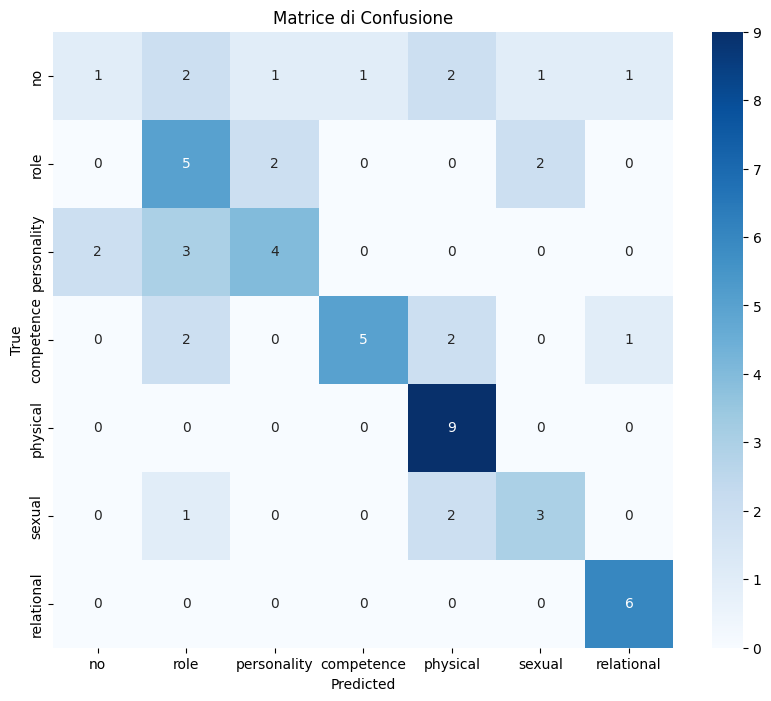



****************************************************************************************************
AVVIO esperimento: BERT_unfreezed
Parametri: Freeze=False |     LR=1e-05 |     Epoche=20 |     Batch=8|     Validation=True
****************************************************************************************************


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Caricamento pesi custom da /content/drive/MyDrive/GSIdetect/weights.pth...
Pesi custom caricati.



Epoch 01/20
TRAIN -> Loss: 2.0514 | F1-Macro: 0.1662
VAL   -> Loss: 1.9577 | F1-Macro: 0.2042
----------------------------------------------------------------------------------------------------


Epoch 02/20
TRAIN -> Loss: 2.0558 | F1-Macro: 0.1283
VAL   -> Loss: 2.0857 | F1-Macro: 0.1065
----------------------------------------------------------------------------------------------------


...

Epoch 19/20
TRAIN -> Loss: 1.1897 | F1-Macro: 0.6790
VAL   -> Loss: 1.5958 | F1-Macro: 0.4483
----------------------------------------------------------------------------------------------------


Epoch 20/20
TRAIN -> Loss: 1.1865 | F1-Macro: 0.6586
VAL   -> Loss: 1.5369 | F1-Macro: 0.3942
----------------------------------------------------------------------------------------------------
Generazione predizioni per analisi errori...


Analyzing: 100%|██████████| 8/8 [00:00<00:00, 17.93it/s]


Analisi degli errori sul Train Set...


,Class,TP (Corretti),FP (Falsi Allarmi),FN (Mancati),Precision,Recall
0,no,3,7,6,0.30,0.33
1,role,7,4,2,0.64,0.78
2,personality,3,4,6,0.43,0.33
3,competence,5,2,5,0.71,0.50
4,physical,7,7,2,0.50,0.78
5,sexual,4,0,2,1.00,0.67
6,relational,5,0,1,1.00,0.83


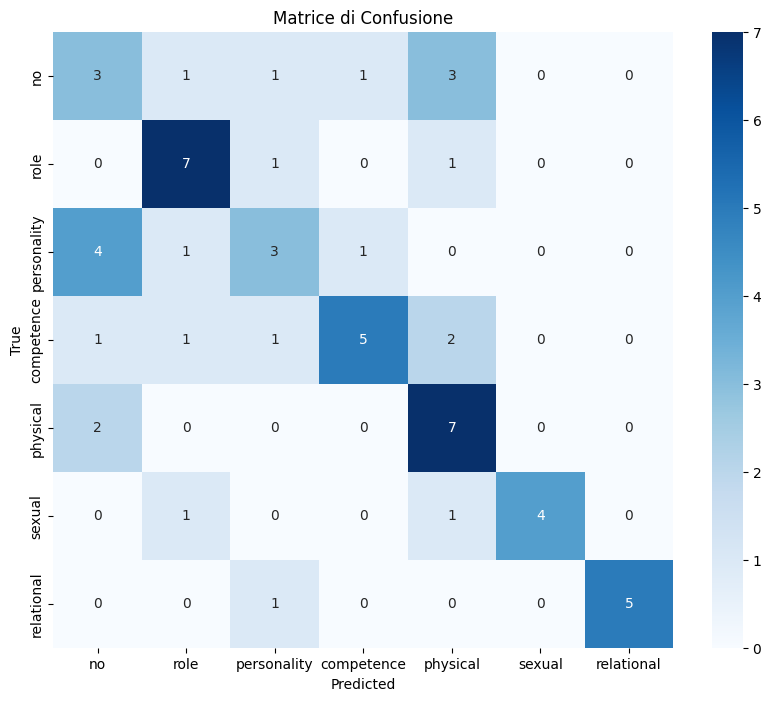



****************************************************************************************************
AVVIO esperimento: BERT_freezed
Parametri: Freeze=True |     LR=0.0005 |     Epoche=15 |     Batch=16|     Validation=False
****************************************************************************************************


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Caricamento pesi custom da /content/drive/MyDrive/GSIdetect/weights.pth...
Pesi custom caricati.



Epoch 01/15
TRAIN -> Loss: 2.0955 | F1-Macro: 0.1361
----------------------------------------------------------------------------------------------------


Epoch 02/15
TRAIN -> Loss: 1.9511 | F1-Macro: 0.2202
----------------------------------------------------------------------------------------------------


...

Epoch 14/15
TRAIN -> Loss: 1.1988 | F1-Macro: 0.6069
----------------------------------------------------------------------------------------------------


Epoch 15/15
TRAIN -> Loss: 1.2594 | F1-Macro: 0.5523
----------------------------------------------------------------------------------------------------

Modello salvato con successo in: /content/drive/MyDrive/GSIdetect/models/BERT_freezed.pth
Generazione predizioni per analisi errori...


Analyzing: 100%|██████████| 23/23 [00:02<00:00,  8.28it/s]


Analisi degli errori sul Train Set...


,Class,TP (Corretti),FP (Falsi Allarmi),FN (Mancati),Precision,Recall
0,no,28,9,31,0.76,0.47
1,role,52,11,8,0.83,0.87
2,personality,36,12,19,0.75,0.65
3,competence,38,4,26,0.90,0.59
4,physical,54,44,1,0.55,0.98
5,sexual,32,2,7,0.94,0.82
6,relational,36,10,0,0.78,1.00


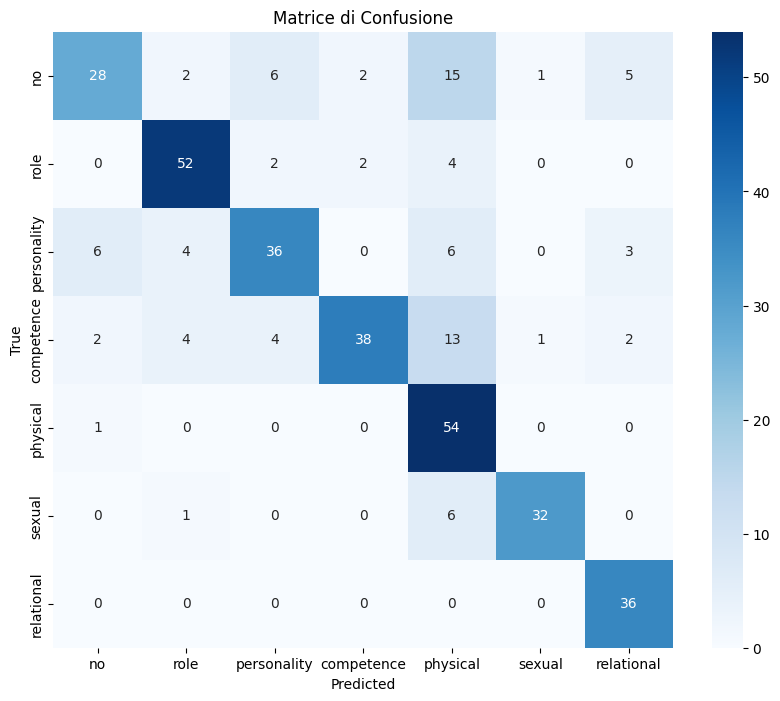


Generazione predizioni sul Test Set...
Generazione predizioni in corso...


Predicting: 100%|██████████| 51/51 [00:06<00:00,  8.27it/s]



File submission salvato in: /content/drive/MyDrive/GSIdetect/submission_BERT_freezed.csv


****************************************************************************************************
AVVIO esperimento: BERT_unfreezed
Parametri: Freeze=False |     LR=1e-05 |     Epoche=18 |     Batch=8|     Validation=False
****************************************************************************************************


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Caricamento pesi custom da /content/drive/MyDrive/GSIdetect/weights.pth...
Pesi custom caricati.



...

Epoch 17/18
TRAIN -> Loss: 1.1773 | F1-Macro: 0.6590
----------------------------------------------------------------------------------------------------


Epoch 18/18
TRAIN -> Loss: 1.1970 | F1-Macro: 0.6401
----------------------------------------------------------------------------------------------------

Modello salvato con successo in: /content/drive/MyDrive/GSIdetect/models/BERT_unfreezed.pth
Generazione predizioni per analisi errori...


Analyzing: 100%|██████████| 47/47 [00:02<00:00, 16.49it/s]



Analisi degli errori sul Train Set...


,Class,TP (Corretti),FP (Falsi Allarmi),FN (Mancati),Precision,Recall
0,no,32,9,26,0.78,0.55
1,role,51,1,9,0.98,0.85
2,personality,47,14,10,0.77,0.82
3,competence,48,2,17,0.96,0.74
4,physical,57,33,0,0.63,1.00
5,sexual,39,2,2,0.95,0.95
6,relational,38,3,0,0.93,1.00


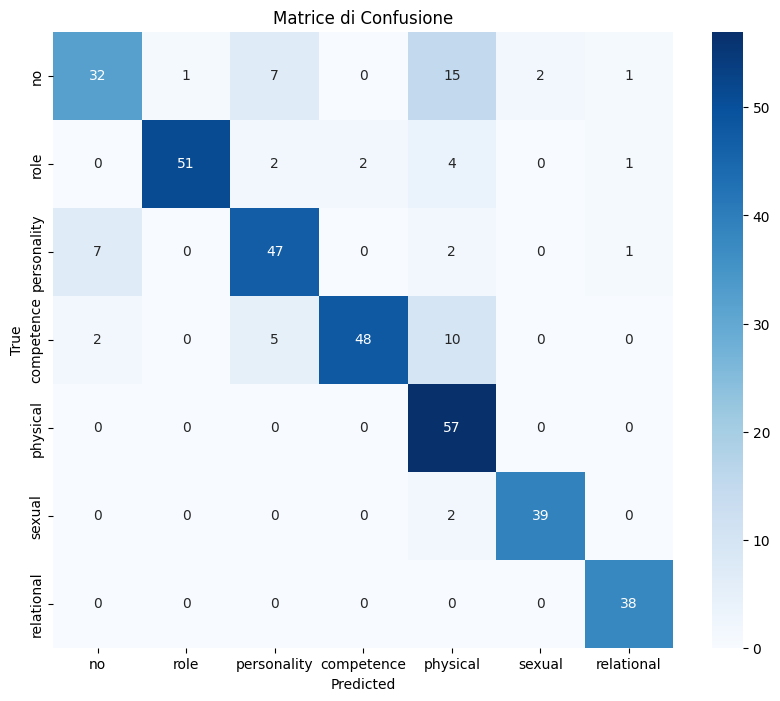


Generazione predizioni sul Test Set...
Generazione predizioni in corso...


Predicting: 100%|██████████| 102/102 [00:06<00:00, 16.73it/s]


File submission salvato in: /content/drive/MyDrive/GSIdetect/submission_BERT_unfreezed.csv


****************************************************************************************************
Run completato


In [ ]:
results = {}

loss_fn = nn.CrossEntropyLoss(weight=weights_tensor)

print(f'Run degli esperimenti')

for experiment in experiments:
    print('\n' * 2 + '*' * 100)
    print(f"AVVIO esperimento: {experiment['nome']}")
    print(f"Parametri: Freeze={experiment['freeze']} | \
    LR={experiment['lr']} | \
    Epoche={experiment['epochs']} | \
    Batch={experiment['batch_size']}| \
    Validation={experiment['validation']}")
    print(f"'*' * 100")

    # Dataloader
    train_loader = DataLoader(
        train_dataset if experiment['validation'] else train_raw_dataset,
        batch_size=experiment['batch_size'],
        shuffle=True,
        drop_last=True)

    val_loader = DataLoader(
        val_dataset,
        batch_size=experiment['batch_size'],
        shuffle=False) if experiment['validation'] else None

    test_loader = DataLoader(
        test_dataset,
        batch_size=experiment['batch_size'],
        shuffle=False)

    # --INIZIALIZZAZIONE--
    model = BERTClassifier(
        n_classes=len(label_map),
        new_vocab_size=len(tokenizer),
        bert_weights_path=bert_weights_path,
        freeze_bert=experiment['freeze']
    ).to(device)

    # Ottimizzatore
    optimizer = torch.optim.AdamW(model.parameters(), lr=experiment['lr'])

    total_steps = len(train_loader) * experiment['epochs']

    # Scheduler
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    history = {'train_loss': [], 'train_f1': [], 'val_loss': [], 'val_f1': []}

    # --ADDESTRAMENTO--
    for epoch in range(experiment['epochs']):
      # Parte del training
      train_acc, train_loss, train_f1 = train_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device,
        len(df_train if experiment['validation'] else df_train_raw),
        scheduler
      )

      history['train_loss'].append(train_loss)
      history['train_f1'].append(train_f1)

      # Parte della validation (opzionale)
      if experiment['validation']:
        val_acc, val_loss, val_true, val_pred = eval_model(
            model,
            val_loader,
            loss_fn,
            device,
            len(df_val)
        )

        val_f1 = f1_score(val_true, val_pred, average='macro')

        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

      # Visualizzazione epoca
      print(f"Epoch {epoch + 1:02d}/{experiment['epochs']}")
      print(f'TRAIN -> Loss: {train_loss:.4f} | F1-Macro: {train_f1:.4f}')
      print(f'VAL   -> Loss: {val_loss:.4f} | F1-Macro: {val_f1:.4f}') if experiment['validation'] else None
      print('-' * 100)

    results[experiment['nome']] = history

    # --SALVATAGGIO--
    save_model(model, experiment['nome']) if not experiment['validation'] else None

    # --PREDIZIONE--
    df_results, conf_matrix, classes = analyze_predictions(
        model,
        val_loader if experiment['validation'] else train_loader,
        device,
        label_map)

    # Visualizzazione tabulare
    print(f"\nAnalisi degli errori sul Train Set...")
    display(df_results)
    print(f" ")

    # Visualizzazione heatmap
    plt.figure(figsize=(10, 8))
    plt.title(f"Confusion Matrix - {experiment['nome']}")
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Matrice di Confusione')
    plt.show()

    # Calcolo delle predizioni
    if not experiment['validation']:
      print(f"\nGenerazione predizioni sul Test Set...")
      raw_predictions = get_predictions(model, test_loader, device)

      idx_to_label = {v: k for k, v in label_map.items()}
      predicted_labels = [idx_to_label[p] for p in raw_predictions]

      # Submission
      submission_df = pd.DataFrame({
          'text': df_test['text'],
          'gs_category': predicted_labels
      })

      csv_path = os.path.join(BASE_PATH, f"submission_{experiment['nome']}.csv")
      submission_df.to_csv(csv_path, index=False)
      print(f"\nFile submission salvato in: {csv_path}")

print('\n' * 2 + '*' * 100)
print("Run completato")